## Customer Churn Prediction using Logistic Regression

### Notebook 04 - Exploratory Data Analysis (EDA)

---

### Introduction

After cleaning and preprocessing the dataset, the next step is to explore the data in greater detail.

Exploratory Data Analysis (EDA) helps us understand the characteristics of the dataset, identify important patterns, discover relationships between variables, detect potential outliers, and gain business insights before building a machine learning model.

The insights obtained during EDA also help in selecting useful features and choosing appropriate preprocessing techniques.

---

### Learning Objectives

By the end of this notebook, you will be able to:

- Load the cleaned dataset
- Understand feature distributions
- Perform univariate analysis
- Perform bivariate analysis
- Explore relationships with the target variable
- Identify important factors affecting customer churn
- Generate business insights from the data

### Step 1 - Import Required Libraries

In this notebook, we require additional visualization libraries to explore the dataset graphically.

These libraries allow us to create informative charts that help reveal hidden trends and relationships within the data.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

### Step 2 - Load the Cleaned Dataset

Instead of loading the raw dataset, we use the cleaned dataset produced in the previous notebook.

Using the cleaned data ensures that our analysis is performed on high-quality and relevant information.

In [3]:
df = pd.read_excel("D:\\machine learning\\machine_learning\\logistic_regression_project\\churn_prediction\\data\\processed_data\\clean_churn.xlsx")

### Step 3 - Display Dataset Information

Before starting the analysis, we verify the structure of the cleaned dataset by checking its dimensions, available features, and data types.

This helps ensure that the preprocessing steps were completed successfully.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

### Step 4 - Generate Statistical Summary

Descriptive statistics provide a quick overview of the numerical features.

Measures such as mean, median, minimum, maximum, and standard deviation help us understand the overall distribution of the data and identify any unusual values.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Tenure Months,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
Monthly Charges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75
Churn Value,7043.0,0.265370,0.441561,0.00,0.0,0.00,1.00,1.00


### Step 5 - Explore Categorical Features

Most customer attributes in this dataset are categorical.

Before visualizing them, we examine the unique values present in each categorical feature to better understand the available categories.

In [6]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{'='*50}")
    print(column)
    print(df[column].value_counts())


Gender
Gender
Male      3555
Female    3488
Name: count, dtype: int64

Senior Citizen
Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     5416
Yes    1627
Name: count, dtype: int64

Phone Service
Phone Service
Yes    6361
No      682
Name: count, dtype: int64

Multiple Lines
Multiple Lines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Internet Service
Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Online Security
Online Security
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

Online Backup
Online Backup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

Device Protection
Device Protection
No                     3095
Yes                    2422
N

This output shows the distribution of each category within the categorical features.

Understanding these categories helps us interpret future visualizations and identify potential class imbalances.

### Step 6 - Analyze the Target Variable

Before building a classification model, it is important to understand the distribution of the target variable.

In this dataset, the target variable is **Churn Label**, which indicates whether a customer has left the company's service.

Visualizing the target variable helps us identify whether the dataset is balanced or imbalanced. A highly imbalanced dataset may require special handling during model training.

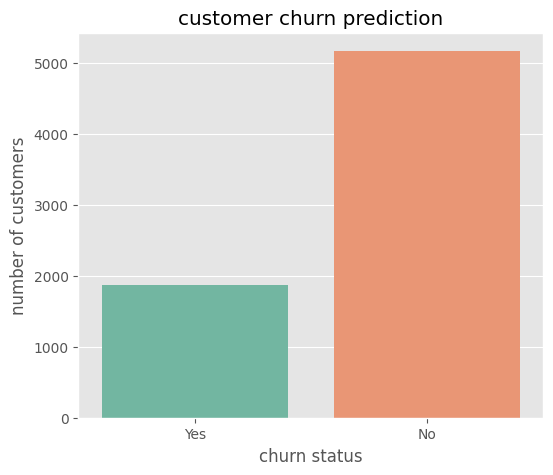

In [9]:
plt.figure(figsize=(6, 5))
sns.countplot(
    data=df,
    x="Churn Label",
    palette="Set2"
)
plt.title("customer churn prediction")
plt.xlabel("churn status")
plt.ylabel("number of customers")
plt.show()

percentage(code)

In [10]:
df["Churn Label"].value_counts(normalize=True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### Observation

The count plot shows the distribution of customers who stayed and those who churned.

By comparing both classes, we can determine whether the dataset is balanced. If one class contains significantly fewer observations than the other, the dataset is considered imbalanced, which may influence model performance.

### Step 7 - Analyze Gender Distribution

Gender is one of the demographic features in the dataset.

This visualization helps us understand whether the customer base is evenly distributed between male and female customers.

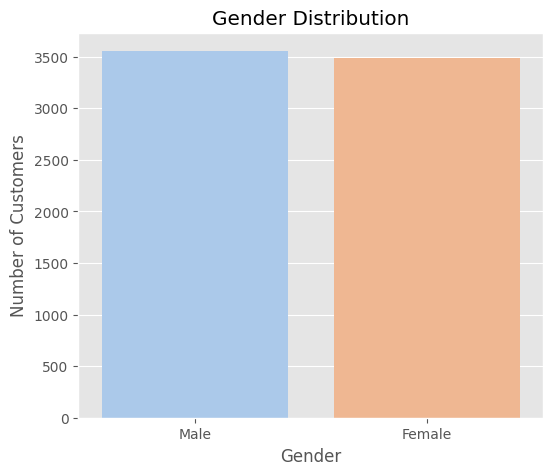

In [11]:
plt.figure(figsize=(6, 5))
sns.countplot(
    data=df,
    x="Gender",
    palette="pastel"
)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

#### Observation

The chart illustrates the proportion of male and female customers.

An approximately equal distribution indicates that the dataset does not have a strong gender imbalance.

### Step 8 - Analyze Contract Types

Customers may subscribe using different contract plans such as Month-to-Month, One Year, or Two Year contracts.

Understanding the distribution of contract types helps identify the most common subscription plan among customers.

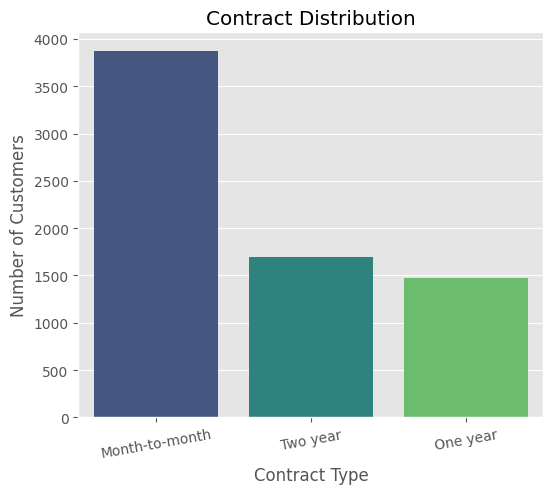

In [13]:
plt.figure(figsize=(6,5))
sns.countplot(
    data=df,
    x="Contract",
    palette="viridis"
)
plt.title("Contract Distribution")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=10)
plt.show()

### Observation

The visualization shows how customers are distributed across different contract types.

Identifying the most common contract plan provides valuable business insight and prepares us for analyzing its relationship with customer churn.

### Step 9 - Analyze Internet Service

Customers subscribe to different internet service types.

Visualizing this feature helps us understand which service is most commonly used among customers.

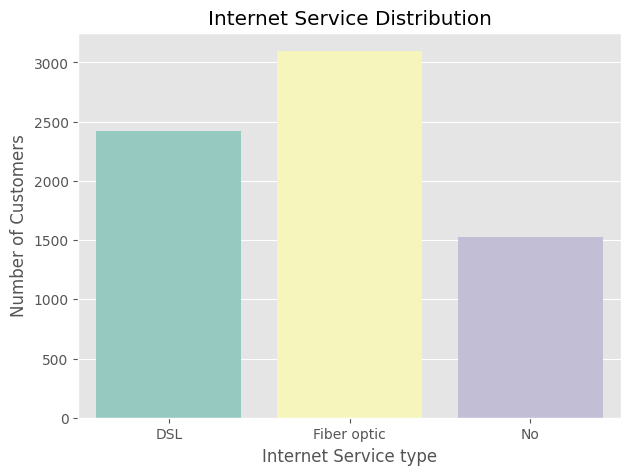

In [20]:
plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x="Internet Service",
    palette="Set3"
)
plt.title("Internet Service Distribution")
plt.xlabel("Internet Service type")
plt.ylabel("Number of Customers")
plt.show()

### Observation

The chart displays the frequency of each internet service category.

This provides an overview of customer preferences before exploring whether certain service types experience higher churn rates.

### tep 10 - Analyze Customer Tenure

Customer tenure represents the number of months a customer has remained with the company.

Understanding the distribution of customer tenure helps identify whether most customers are new or long-term subscribers. This information is valuable because customer loyalty often influences churn behavior.

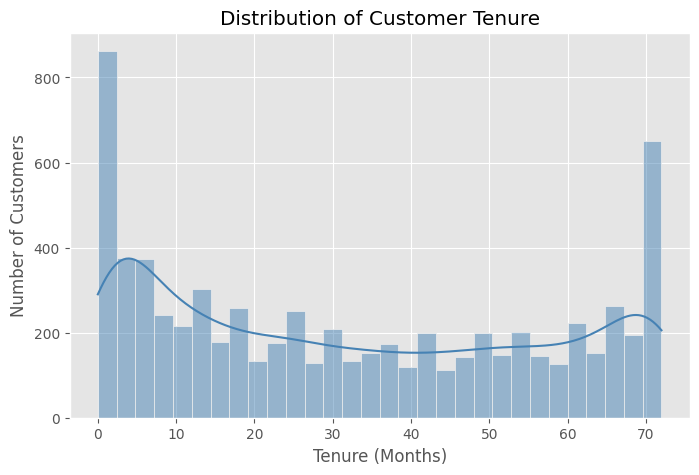

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Tenure Months",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The histogram illustrates how customer tenure is distributed across the dataset.

The Kernel Density Estimate (KDE) curve provides a smooth representation of the distribution, making it easier to identify peaks, skewness, and customer concentration.

## Step 11 - Analyze Monthly Charges

Monthly Charges represent the amount each customer pays every month.

Visualizing this feature helps us understand the pricing distribution and identify whether customers are concentrated within specific pricing ranges.

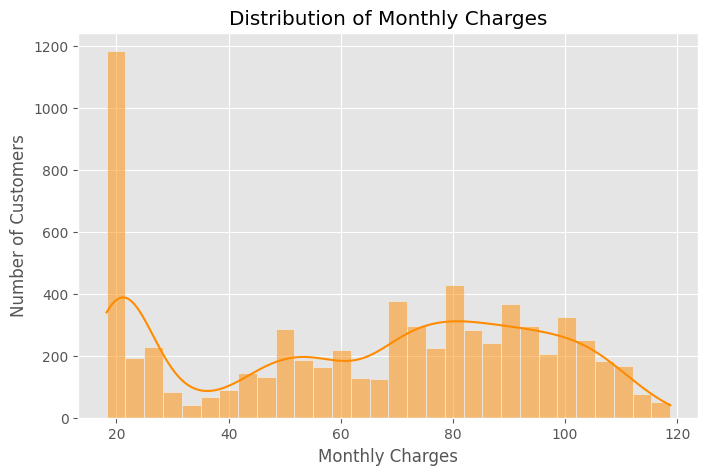

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Monthly Charges",
    bins=30,
    kde=True,
    color="darkorange"
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

### tep 12 - Analyze Total Charges

Total Charges represent the cumulative amount paid by a customer during their relationship with the company.

This feature often reflects both customer tenure and monthly subscription cost, making it an important variable for understanding customer value.

In [26]:
# 1. Convert spaces/strings to float; bad values (like " ") become NaN
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

# 2. Fill NaN values with 0 (or drop them with df.dropna(subset=["Total Charges"]))
df["Total Charges"] = df["Total Charges"].fillna(0)

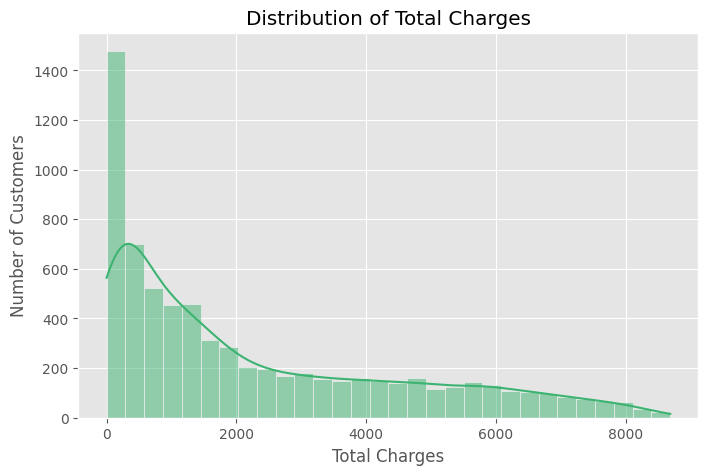

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Total Charges",
    bins=30,
    kde=True,
    color="mediumseagreen"
)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The distribution of Total Charges helps identify spending patterns across customers.

Higher total charges generally indicate customers who have remained with the company for a longer period or subscribed to higher-priced services.

### tep 13 - Detect Outliers

Box plots provide a simple way to identify potential outliers within numerical features.

Outliers are observations that lie significantly outside the typical range of the data. Detecting them is important because extreme values can influence statistical analysis and machine learning models.

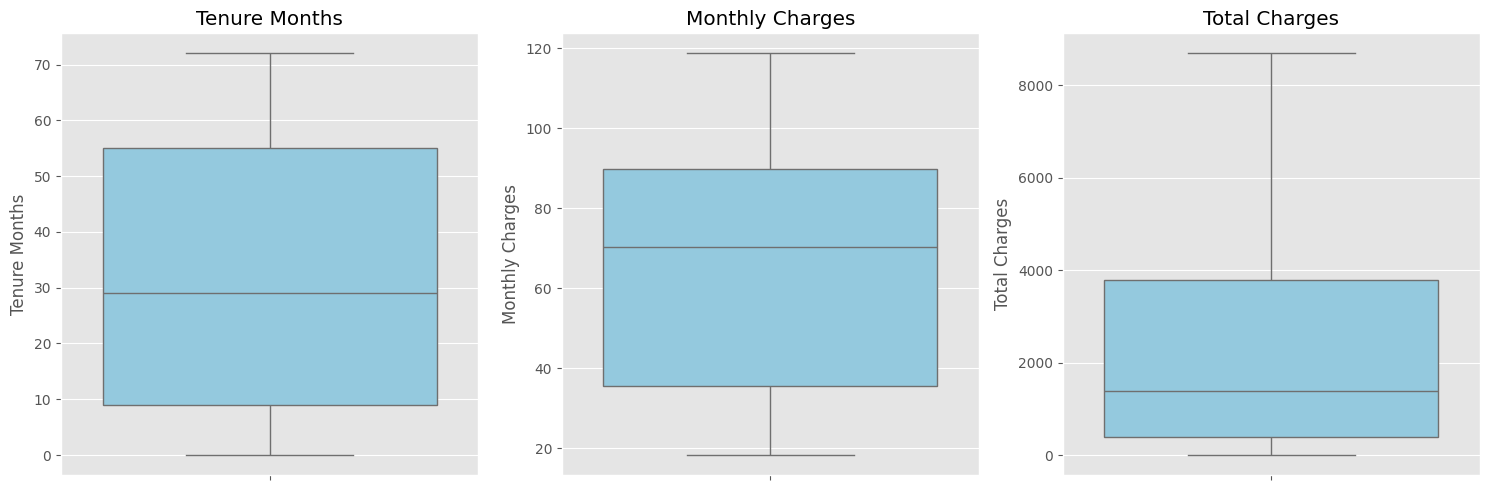

In [28]:
numerical_columns = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

plt.figure(figsize=(15,5))

for i, column in enumerate(numerical_columns, 1):

    plt.subplot(1,3,i)

    sns.boxplot(
        y=df[column],
        color="skyblue"
    )

    plt.title(column)

plt.tight_layout()
plt.show()

### Observation

The box plots display the spread of each numerical feature along with any potential outliers.

Outliers should not be removed automatically. Their impact should be evaluated carefully, especially in business datasets where extreme values may represent genuine customer behavior rather than errors.